In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skdim
# load .mat data
import scipy.io
from scipy.linalg import pinvh

%load_ext autoreload
%autoreload 2

# load data
folder = "/Users/donglaiyang/Documents/Documents_Alastair’s_MacBook_Pro/Georgia-Tech/Research/GMR-inference/data/training/gridded/"
X_filename = 'trainingAll4D_Eb_sim_standardized.mat'
Y_filename = 'trainingAll4D_Em_sim_masked_standardized.mat'
H_filename = 'H_gridded.mat'
mask_filename = 'training_mask.mat'

X_data = scipy.io.loadmat(folder + X_filename)
Y_data = scipy.io.loadmat(folder + Y_filename)
mask_data = scipy.io.loadmat(folder + mask_filename)
H_data = scipy.io.loadmat(folder + H_filename)

Shape of Eb_standardized: (256, 256, 1, 742)
Shape of Em_standardized: (256, 256, 1, 742)
Shape of mask: (256, 256)


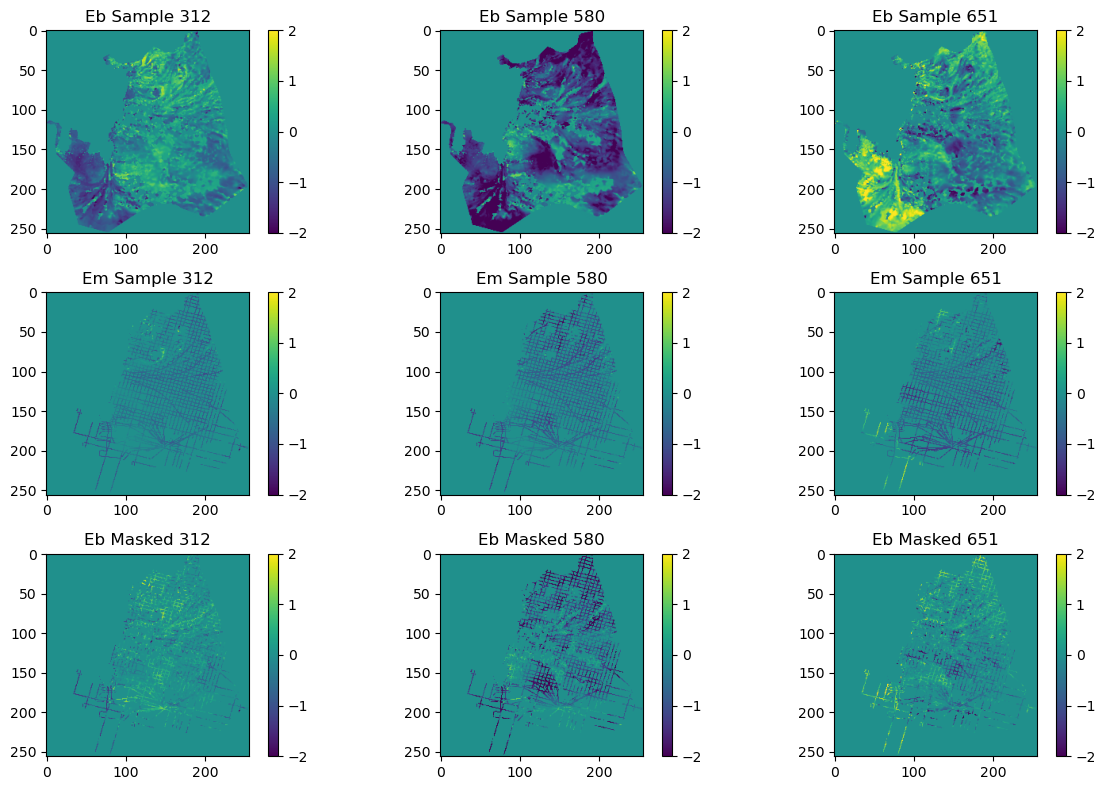

In [2]:
Eb_standardized = X_data['Eb_standardized']
Em_standardized = Y_data['Em_standardized_masked']
mask = mask_data['mask']
print('Shape of Eb_standardized:', Eb_standardized.shape)
print('Shape of Em_standardized:', Em_standardized.shape)
print('Shape of mask:', mask.shape)

# create a masked version of Eb 
# this is for building PCA principal components for Y later
Eb_standardized_masked = Eb_standardized * mask.reshape(*mask.shape, 1, 1)

# plot three random samples (Eb and Em) for visual
num_samples = Eb_standardized.shape[3]
random_indices = np.random.choice(num_samples, size=3, replace=False)
# figure size
plt.figure(figsize=(12, 8))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(Eb_standardized[:, :, :, idx], cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Eb Sample {idx}')
    plt.colorbar()
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 4)
    plt.imshow(Em_standardized[:, :, :, idx], cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Em Sample {idx}')
    plt.colorbar()
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 7)
    plt.imshow(Eb_standardized_masked[:, :, :, idx], cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Eb Masked {idx}')
    plt.colorbar()

plt.tight_layout()
plt.show()

### Investigate the relationship between ensemble size and intrinsic dimension

shape of data_reshaped: (742, 65536)


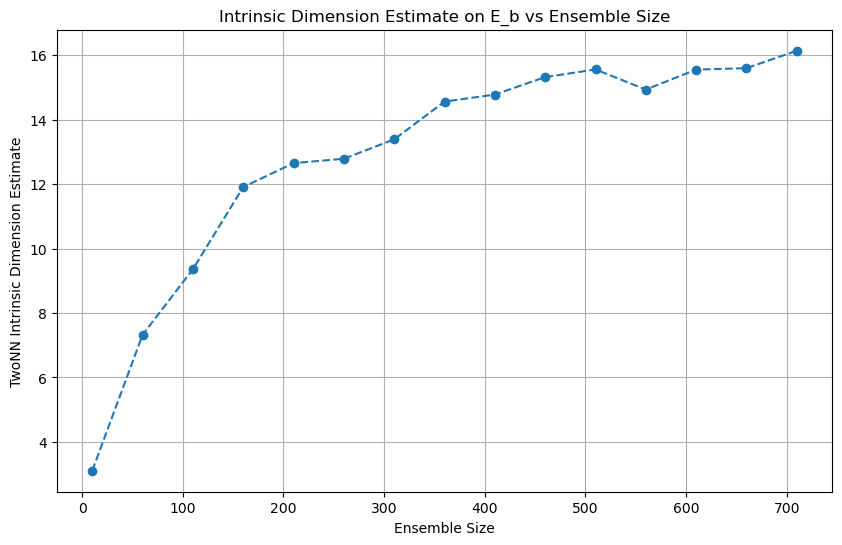

In [3]:
# randomly shuffle data_reshaped
# apply the same analysis to Eb_standardized data, which now has dimension (nx, ny, 1, n_samples) where nx*ny is the full spatial dimension for each sample
nx, ny, _, n_samples = Eb_standardized.shape
data_reshaped = Eb_standardized.reshape((nx * ny, n_samples)).T
print('shape of data_reshaped:', data_reshaped.shape)

np.random.seed(0)
shuffled_indices = np.random.permutation(data_reshaped.shape[0])
data_shuffled = data_reshaped[shuffled_indices]

ensemble_size = range(10, n_samples + 1, 50)
townn_estimates = []

for size in ensemble_size:
    subset = data_shuffled[:size,:]
    twonn = skdim.id.TwoNN().fit(subset)
    townn_estimates.append(twonn.dimension_)

# Plot intrinsic dimension estimates vs ensemble size
plt.figure(figsize=(10, 6))
plt.plot(ensemble_size, townn_estimates, marker='o', linestyle='--')
plt.xlabel('Ensemble Size')
plt.ylabel('TwoNN Intrinsic Dimension Estimate')
plt.title('Intrinsic Dimension Estimate on E_b vs Ensemble Size')
plt.grid()
plt.show()

### Compare PCA to the intrinsic dimension estimates

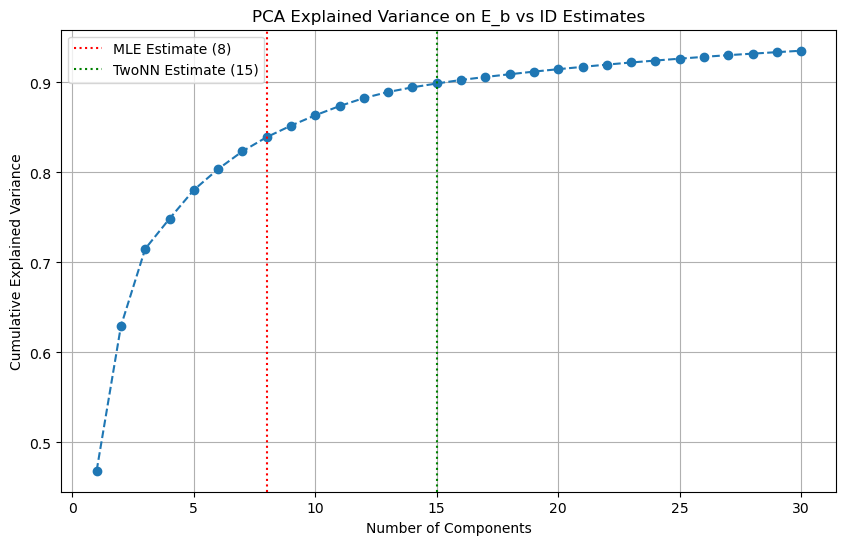

Variance at 8 dims: 0.839
Variance at 15 dims: 0.899


In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA
pca = PCA(n_components=30) # Look at top 30
pca.fit(data_reshaped)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), cumulative_variance, marker='o', linestyle='--')
plt.axvline(x=8, color='r', linestyle=':', label='MLE Estimate (8)')
plt.axvline(x=15, color='g', linestyle=':', label='TwoNN Estimate (15)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance on E_b vs ID Estimates')
plt.legend()
plt.grid(True)
plt.show()

# Check values
print(f"Variance at 8 dims: {cumulative_variance[7]:.3f}")
print(f"Variance at 15 dims: {cumulative_variance[14]:.3f}")


In [5]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


# apply the same analysis to Eb_standardized data, which now has dimension (nx, ny, 1, n_samples) where nx*ny is the full spatial dimension for each sample
nx, ny, _, n_samples = Eb_standardized.shape
X_reshaped = Eb_standardized.reshape((nx * ny, n_samples)).T
# Y_reshaped = Eb_standardized_masked.reshape((nx * ny, n_samples)).T
Y_reshaped = Em_standardized.reshape((nx * ny, n_samples)).T
print('shape of X_reshaped:', X_reshaped.shape)
print('shape of Y_reshaped:', Y_reshaped.shape)

# 1. PCA Step: Compress 65k -> 18 dimensions
# We choose 18 to capture slightly more than the TwoNN estimate (buffer for curvature)
pca_X = PCA(n_components=25) 
X_reduced = pca_X.fit_transform(X_reshaped)

pca_Y = PCA(n_components=20)
Y_reduced = pca_Y.fit_transform(Y_reshaped)

print(f"Explained Variance (X): {np.sum(pca_X.explained_variance_ratio_):.3f}")
print(f"Explained Variance (Y): {np.sum(pca_Y.explained_variance_ratio_):.3f}")

# # We don't need Y_reduced. We need the learned pca_Y components to apply to Em_standardized
# Y_components = pca_Y.components_  # shape (18, 65536)
# Y_reshaped = Em_standardized.reshape((nx * ny, n_samples)).T
# Y_reduced = pca_Y.transform(Y_reshaped)  # shape (n_samples, 18)


shape of X_reshaped: (742, 65536)
shape of Y_reshaped: (742, 65536)
Explained Variance (X): 0.926
Explained Variance (Y): 0.992


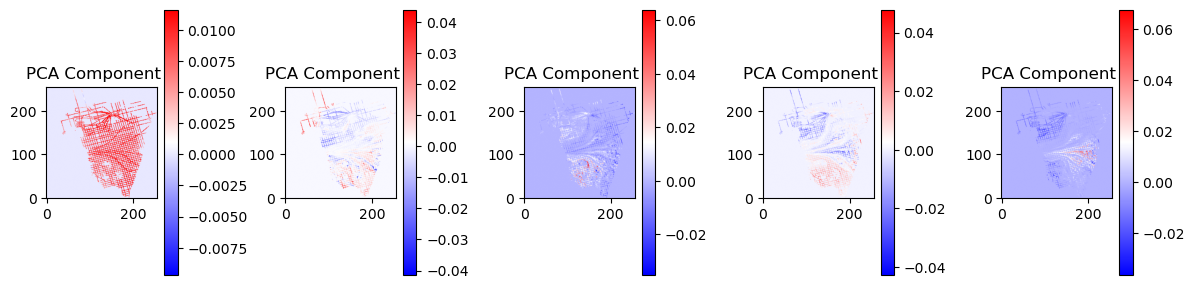

In [6]:
# visualize the first 5 PCA components for Y
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    component_img = pca_Y.components_[i].reshape((nx, ny))
    plt.imshow(component_img, cmap='bwr')
    plt.title(f'PCA Component {i+1}')
    plt.colorbar()
    plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

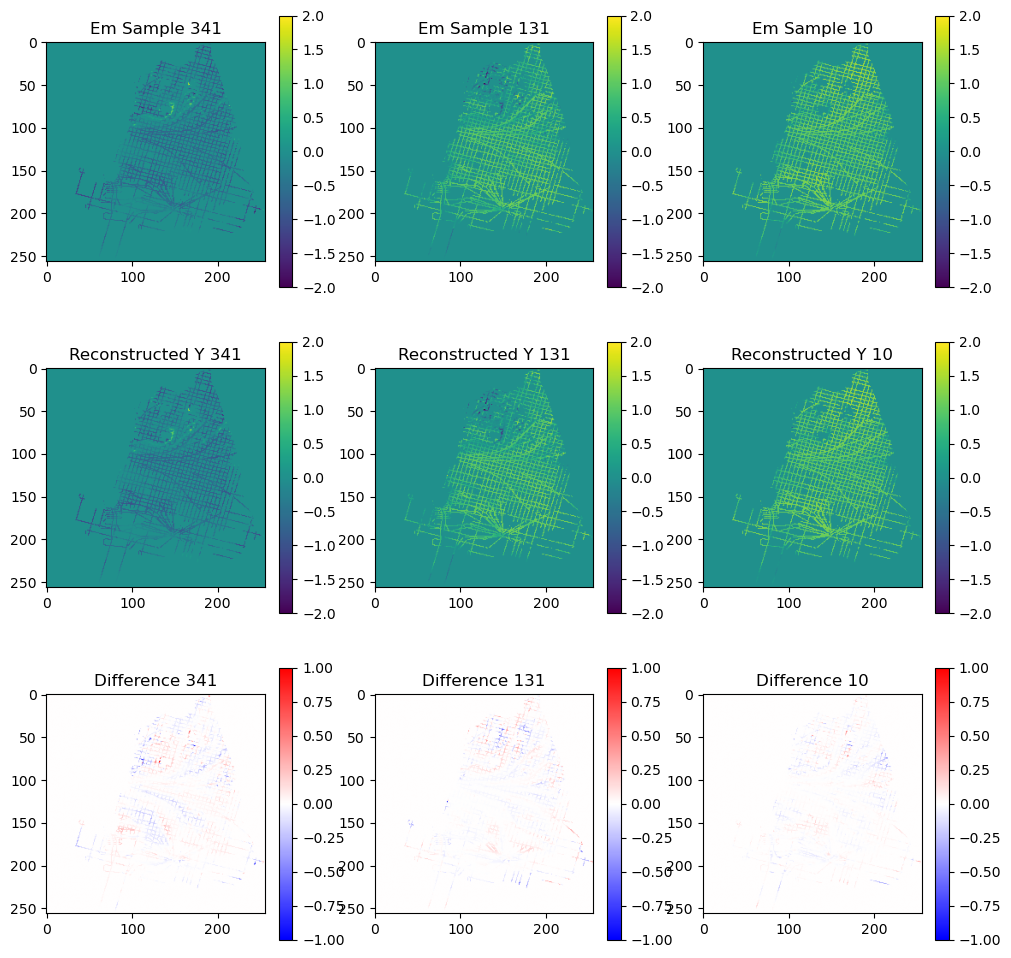

In [7]:
# check how well reconstructed Y_reduced using the PCA components learned from Eb_standardized_masked 
# can capture the variance in Em_standardized
reconstructed_Y = pca_Y.inverse_transform(Y_reduced)  # shape (n_samples, 65536)

# visualize three random samples
random_indices = np.random.choice(n_samples, size=3, replace=False)
plt.figure(figsize=(12, 12))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(Em_standardized[:, :, :, idx], cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Em Sample {idx}')
    plt.colorbar()
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 4)
    plt.imshow(reconstructed_Y[idx].reshape(nx, ny), cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Reconstructed Y {idx}')
    plt.colorbar()
# difference
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 7)
    plt.imshow(Em_standardized[:, :, :, idx].squeeze() - reconstructed_Y[idx].reshape(nx, ny), cmap='bwr', vmin = -1, vmax = 1)
    plt.title(f'Difference {idx}')
    plt.colorbar()

# Using Gaussian Mixture model on the latent space

In [8]:
from gmr.utils import check_random_state
from gmr import MVN, GMM, plot_error_ellipses
from gmr.mvn import regression_coefficients
from gmr.gmm import _safe_probability_density

from scipy.sparse.linalg import eigsh, LinearOperator
from scipy.spatial import cKDTree
import time

from src.amortization import form_obs_cov_col, build_spatial_covariance_operator, sample_from_spatial_cov, pushforward, propagate_uncertainty

shape of XY_train: (667, 45)
shape of XY_test: (75, 45)
shape of XY_train: (667, 45)
shape of XY_test: (75, 45)


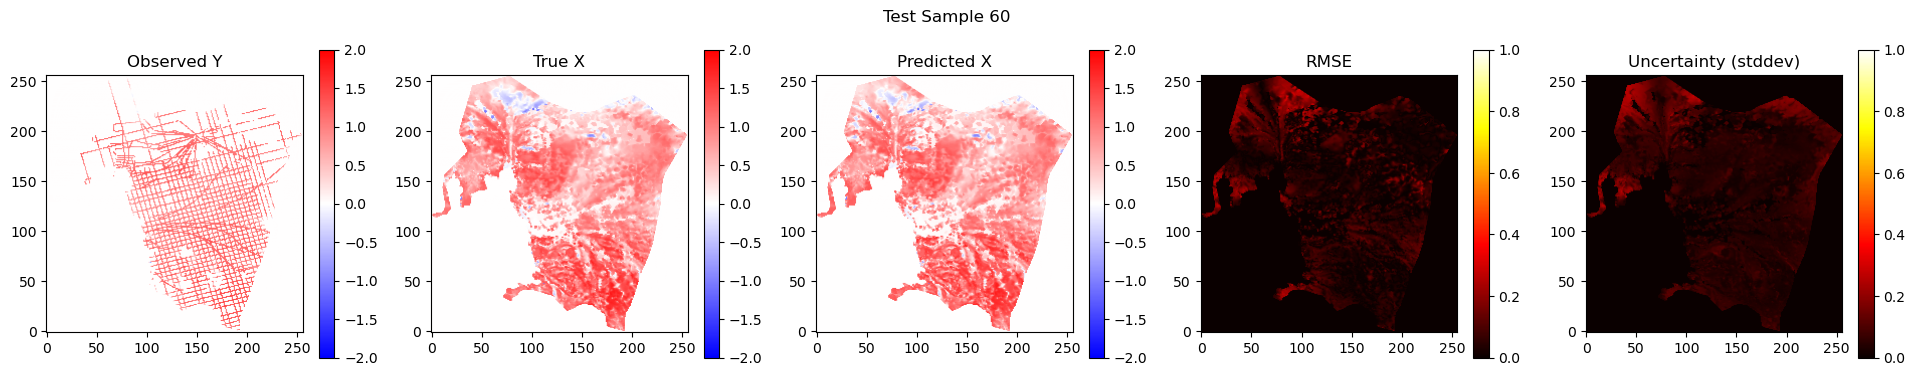

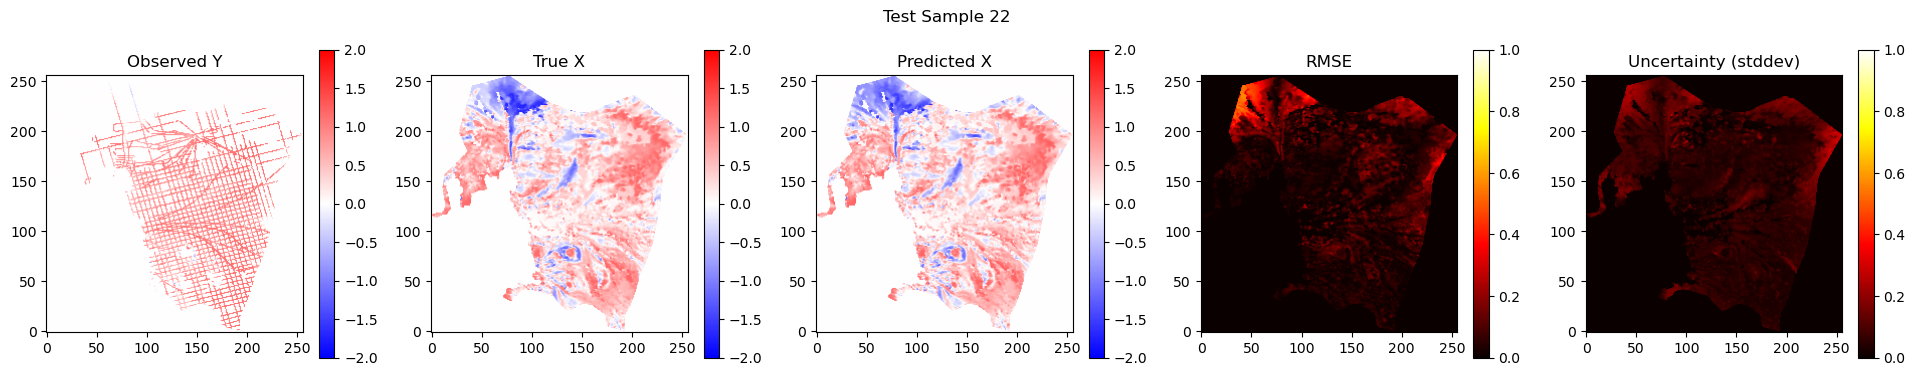

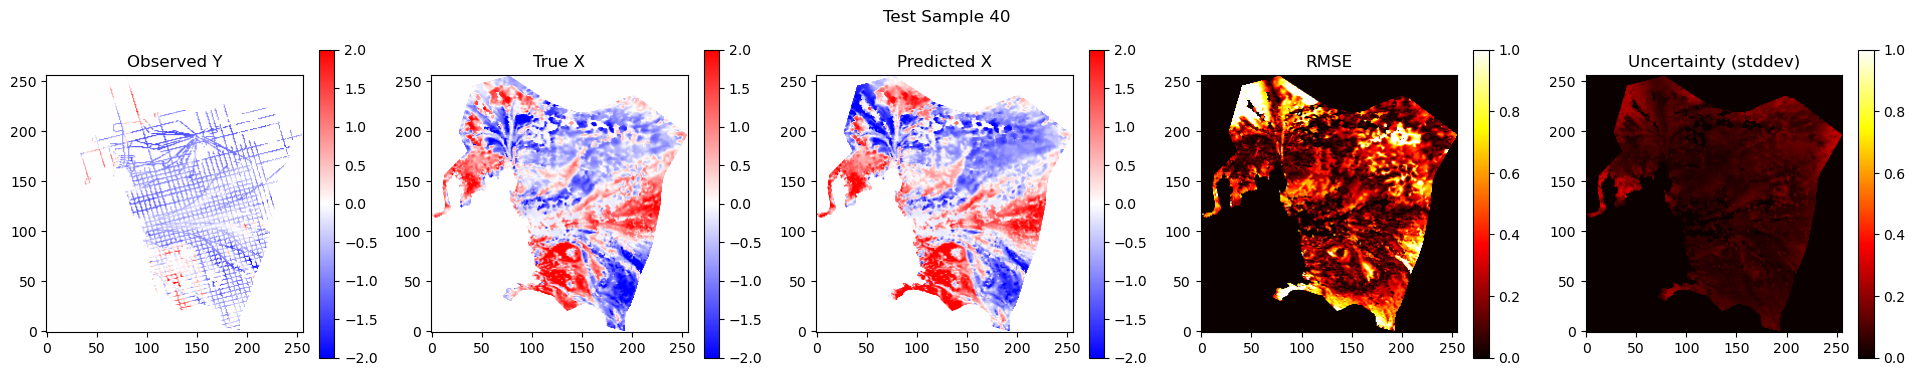

In [9]:
ndim_X = X_reduced.shape[1]
ndim_Y = Y_reduced.shape[1]

random_state = check_random_state(42)
# mvn = GMM(n_components = 10, random_state=random_state)
mvn = MVN(random_state=random_state)

# combine the reduced dimension of X and Y along the column dimension
XY_reduced = np.hstack((Y_reduced, X_reduced))

# shuffle and split a subset for training (90%) and testing (10%)
n_samples = XY_reduced.shape[0]
indices = np.arange(n_samples)
random_state.shuffle(indices)
split_point = int(0.9 * n_samples)
train_indices = indices[:split_point]
test_indices = indices[split_point:]
XY_train = XY_reduced[train_indices]
XY_test = XY_reduced[test_indices]

print('shape of XY_train:', XY_train.shape)
print('shape of XY_test:', XY_test.shape)

ndim_X = X_reduced.shape[1]
ndim_Y = Y_reduced.shape[1]

random_state = check_random_state(42)
gmm = GMM(n_components=20, random_state=random_state)

# combine the reduced dimension of X and Y along the column dimension
# notice here that Y is before X, which means the first few dimensions are Y.T
# we need to be consistent later on when supplying the condition index during our inference stage.
XY_reduced = np.hstack((Y_reduced, X_reduced))

# shuffle and split a subset for training (90%) and testing (10%)
n_samples = XY_reduced.shape[0]
indices = np.arange(n_samples)
random_state.shuffle(indices)
split_point = int(0.9 * n_samples)
train_indices = indices[:split_point]
test_indices = indices[split_point:]
XY_train = XY_reduced[train_indices]
XY_test = XY_reduced[test_indices]

print('shape of XY_train:', XY_train.shape)
print('shape of XY_test:', XY_test.shape)

# create GMM, P(Y,X)
gmm.from_samples(XY_train)

# test first three samples from the test set and visualize the prediction
n_test_samples = len(test_indices)
n_test_samples_plot = 3 
rand_idx = np.random.choice(range(n_test_samples), size=n_test_samples_plot, replace=False)
for i in rand_idx:
    y_test = XY_test[i, :ndim_Y]  # Y part
    x_test = XY_test[i, ndim_Y:]  # X part

    # Predict X given Y
    condition_index = np.arange(ndim_Y)
    x_pred_gmm = gmm.condition(condition_index, y_test)

    # sample from this conditional distribution to get uncertainty
    n_uq_sample = 400
    x_uq_samples = x_pred_gmm.sample(n_uq_sample)
    x_uq_samples_ori = np.zeros((256*256, n_uq_sample))
    # Inverse transform to original space
    # then the uq samples
    for j, sample in enumerate(x_uq_samples):
        x_uq_samples_ori[:,j] = pca_X.inverse_transform(sample)

    # compute the mean from the ensemble
    x_pred_mean = np.mean(x_uq_samples_ori, axis=1)
    x_pred_img = x_pred_mean.reshape(256, 256)
    
    # compute std along each dimension of the uq samples
    x_uq_std = np.std(x_uq_samples_ori, axis=1)
    x_uq_std = x_uq_std.reshape(256, 256)

    # Reshape X for visualization
    x_test_original = pca_X.inverse_transform(x_test.reshape(1, -1))
    x_test_img = x_test_original.reshape(256, 256)

    # observed Y
    obs_Y = pca_Y.inverse_transform(y_test)
    obs_Y = obs_Y.reshape(256, 256)
    # Plotting: five columns: observed Y, True X, predicted X, error (RMSE), uncertainty (stddev)
    plt.figure(figsize=(24, 4))
    plt.subplot(1, 5, 1)
    plt.imshow(obs_Y, cmap='bwr', vmin=-2, vmax=2)
    plt.title('Observed Y')
    plt.colorbar()
    # invert y axis
    plt.gca().invert_yaxis()

    plt.subplot(1, 5, 2)
    plt.imshow(x_test_img, cmap='bwr', vmin=-2, vmax=2)
    plt.title('True X')
    plt.colorbar()
    plt.gca().invert_yaxis()

    plt.subplot(1, 5, 3)
    plt.imshow(x_pred_img, cmap='bwr', vmin=-2, vmax=2)
    plt.title('Predicted X')
    plt.colorbar()
    plt.gca().invert_yaxis()
    
    plt.subplot(1, 5, 4)
    rmse_img = np.sqrt((x_test_img - x_pred_img) ** 2)
    plt.imshow(rmse_img, cmap='hot', vmin = 0, vmax = 1)
    plt.title('RMSE')
    plt.colorbar()
    plt.gca().invert_yaxis()

    plt.subplot(1, 5, 5)
    plt.imshow(x_uq_std, cmap='hot', vmin = 0, vmax = 1)
    plt.title('Uncertainty (stddev)')
    plt.colorbar()
    plt.gca().invert_yaxis()

    plt.suptitle(f'Test Sample {i+1}')
    # save the figure, dpi = 300
    plt.savefig(f'test_sample_{i+1}_prediction.png', dpi=300)
    plt.show()




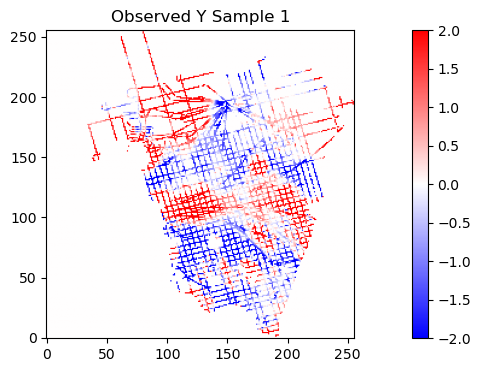

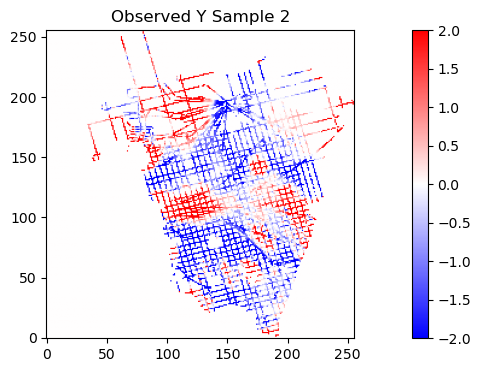

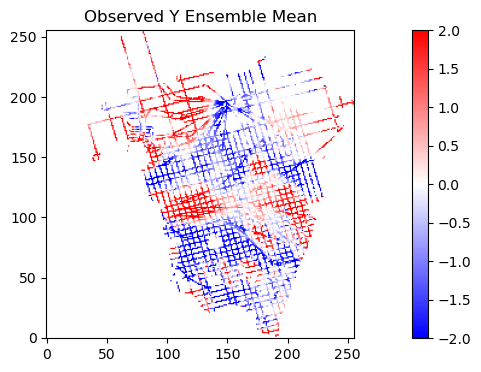

In [10]:
# load observed Y data
Y_obs_filename = "Em_gridded_masked_standardized_ensemble.mat"
Y_obs_data = scipy.io.loadmat(folder + Y_obs_filename)

Y_obs_data = Y_obs_data['Em_obs_standard_ensemble_struct']
Y_obs_data = Y_obs_data['data'][0][0]

# plot the first three samples of Y obs
for i in range(2):
    Y_obs_sample = Y_obs_data[:, :, i]
    plt.figure(figsize=(15, 4))
    plt.imshow(Y_obs_sample, cmap='bwr', vmin=-2, vmax=2)
    plt.title(f'Observed Y Sample {i+1}')
    plt.colorbar()
    plt.gca().invert_yaxis()
    plt.show()

# compute the ensemble mean
Y_obs_mean = np.mean(Y_obs_data, axis=2)
plt.figure(figsize=(15, 4))
plt.imshow(Y_obs_mean, cmap='bwr', vmin=-2, vmax=2)
plt.title('Observed Y Ensemble Mean')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

In [11]:
VT = pca_Y.components_
print("VT has the shape of :", VT.shape)
print("where the 1st dim is latent space dim, and 2nd dim is the original dim")
y_latent_dim = VT.shape[0]
y_data_dim = VT.shape[1]

VT has the shape of : (20, 65536)
where the 1st dim is latent space dim, and 2nd dim is the original dim


In [12]:
# construct a covariance matrix for the observation to account for epstemic uncertainty
# we need the mask array and ice thickness array
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
# for the V^T * Cov matrix, which is of size (k, N) where k is latent dim of Y, and N is the original dim

# mask = mask.flatten().astype(bool)
# loc_idx = 1000
# # try for the first column: find the first x index where mask is True
# first_colnum = np.where(mask)[0][loc_idx]
# print("first column index is :", first_colnum)
# print("Confirm: mask at this location is :", mask[first_colnum])

# cov_col_1 = form_obs_cov_col(H, X, Y, mask, first_colnum) 
# # reshape back and visualize
# cov_col_1_img = cov_col_1.reshape(256, 256)
# plt.figure(figsize=(6, 5))
# plt.imshow(cov_col_1_img, cmap='hot')
# plt.title(f'Covariance Matrix Column for Observed Location {loc_idx}')
# plt.colorbar()
# plt.gca().invert_yaxis()
# plt.show()


In [13]:
# sampling from the covariance explictly
# 1. Build the operator ONCE
Sigma_op, _ = build_spatial_covariance_operator(H, X, Y, mask)

# use PCA-reconstructed Y_obs_mean for consistency with the analytical propagation later
mu_obs_latent = pca_Y.transform(Y_obs_mean.reshape(1, -1))
mu_obs_reconstructed = pca_Y.inverse_transform(mu_obs_latent).reshape(256, 256)

# 2. Use it for MC Sampling Validation
samples, samples_zeromean, _ = sample_from_spatial_cov(H, X, Y, mask, mean = mu_obs_reconstructed, sigma_op=Sigma_op, num_samples=300, 
                                        rank=100, cutoff_factor=5.0, tol=1e-3, verbose=True)

Building Operator | Size: n = 65,536
Valid points: 9,885 | Length scale: 200.0 km
Building spatial index (KD-tree)...
Precomputing neighbor lists...
Avg neighbors: 9885 | Sparsity: 15.08%

Estimating total variance (trace)...
Estimated total variance: 5.66e+03

Computing top 100 eigenvectors...
Eigendecomposition done in 58.5s
Generating 300 samples...


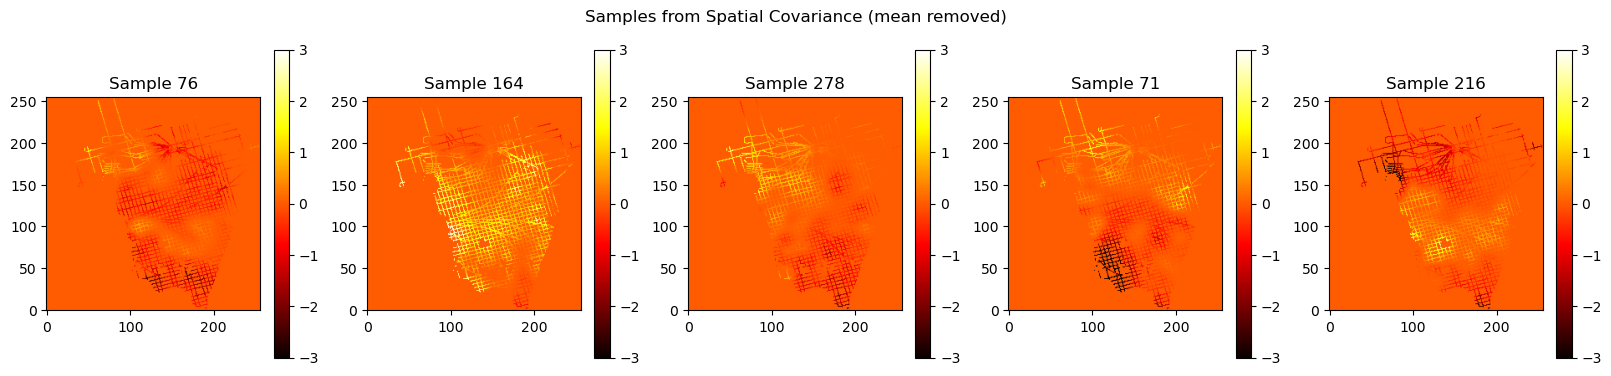

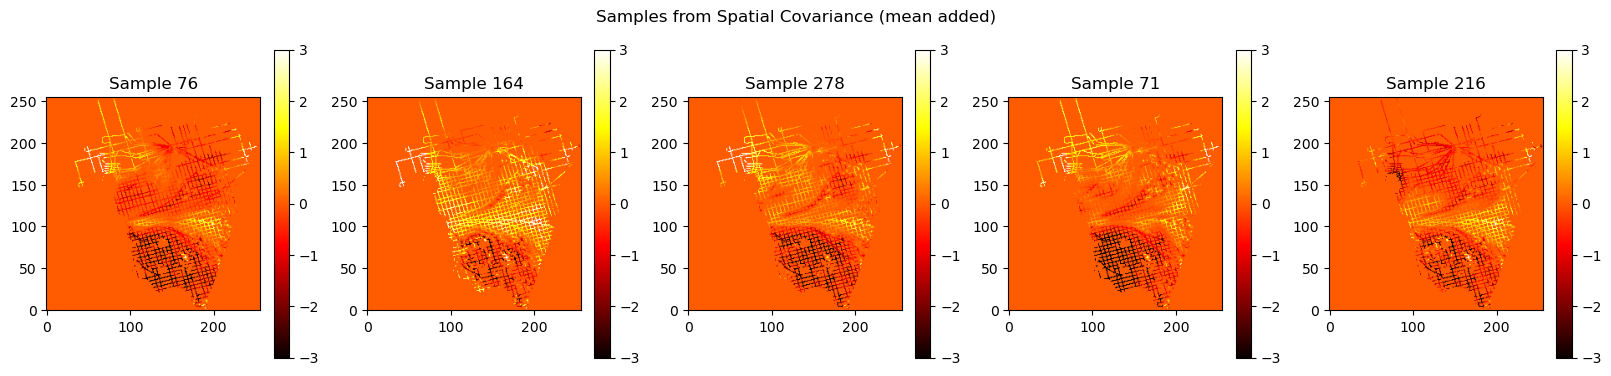

In [14]:
# visualize 5 random samples from 'samples'
# need to reshape each sample back to 256x256
n_samples_to_plot = 5
sample_indices = np.random.choice(samples.shape[1], n_samples_to_plot, replace=False)
plt.figure(figsize=(20, 4))
for i, idx in enumerate(sample_indices):    
    sample_img = samples_zeromean[:, idx].reshape(256, 256)
    plt.subplot(1, n_samples_to_plot, i+1)
    plt.imshow(sample_img, cmap='hot', vmin=-3, vmax=3)
    plt.title(f'Sample {idx}')
    plt.colorbar()
    plt.gca().invert_yaxis()
plt.suptitle('Samples from Spatial Covariance (mean removed)')
plt.show()

plt.figure(figsize=(20, 4))
for i, idx in enumerate(sample_indices):    
    sample_img = samples[:, idx].reshape(256, 256)
    plt.subplot(1, n_samples_to_plot, i+1)
    plt.imshow(sample_img, cmap='hot', vmin=-3, vmax=3)
    plt.title(f'Sample {idx}')
    plt.colorbar()
    plt.gca().invert_yaxis()
plt.suptitle('Samples from Spatial Covariance (mean added)')
plt.show()

In [15]:
# 1. Fix PCA: Use transform, not fit_transform
# Ensure pca_Y is the object fitted on the original training data
Em_obs_reduced = np.transpose(pca_Y.transform(samples.T)) 

obs_uq_n_samples = samples.shape[1]
inner_n_samples = 200

condition_index = np.arange(ndim_Y) # Ensure this matches your GMM dims

inner_sample_mean_sum = np.zeros(256*256)
print(f"Propagating {obs_uq_n_samples} samples")

# first pass: sapmling to get expected values
for i in range(obs_uq_n_samples):
    # Get the conditional GMM: P(X | Y=y_i)
    # This is an analytical operation on the GMM
    pred_gmm = gmm.condition(condition_index, Em_obs_reduced[:,i])
    inner_samples = pred_gmm.sample(inner_n_samples)
    inner_samples_ori = np.zeros((256*256, inner_n_samples))
    # Inverse transform to original space
    # then the uq samples
    for j, sample in enumerate(inner_samples):
        inner_samples_ori[:,j] = pca_X.inverse_transform(sample)
    inner_sample_mean_sum += np.mean(inner_samples_ori, axis=1)
total_mean = inner_sample_mean_sum / obs_uq_n_samples

# second pass: sampling to get stddev
inner_sample_var_sum = np.zeros(256*256)
for i in range(obs_uq_n_samples):
    # Get the conditional GMM: P(X | Y=y_i)
    # This is an analytical operation on the GMM
    pred_gmm = gmm.condition(condition_index, Em_obs_reduced[:,i])
    inner_samples = pred_gmm.sample(inner_n_samples)
    inner_samples_ori = np.zeros((256*256, inner_n_samples))
    # Inverse transform to original space
    # then the uq samples
    for j, sample in enumerate(inner_samples):
        inner_samples_ori[:,j] = pca_X.inverse_transform(sample)
    inner_sample_var_sum += np.sum((inner_samples_ori - total_mean.reshape(-1,1))**2, axis=1)
total_var = inner_sample_var_sum / (obs_uq_n_samples * inner_n_samples)
total_std = np.sqrt(total_var)

# Reshape for visualization
Eb_uq_mean_img = total_mean.reshape(256, 256)
Eb_uq_std_img = total_std.reshape(256, 256)

print(f"MC Validation Complete.")
print(f"Mean Range: [{total_mean.min():.3f}, {total_mean.max():.3f}]")


Propagating 300 samples
MC Validation Complete.
Mean Range: [-15.020, 7.667]


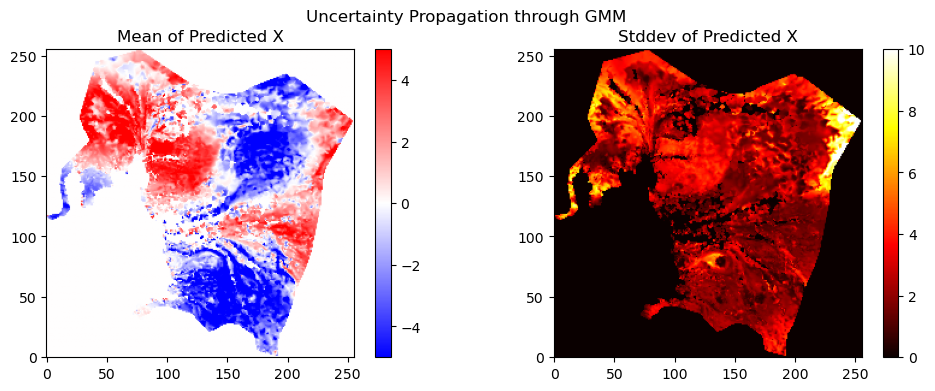

In [16]:
# plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(Eb_uq_mean_img, cmap='bwr', vmin=-5, vmax=5)
plt.title('Mean of Predicted X')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(Eb_uq_std_img, cmap='hot', vmin=0, vmax=10)
plt.title('Stddev of Predicted X')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('Uncertainty Propagation through GMM')

plt.show()

### Analytical propagation of uncertainty

In [17]:
VT = pca_Y.components_ 
n_components = VT.shape[0]
Sigma_VT = np.zeros_like(VT.T) # (N, k)

for k in range(n_components):
    # Apply operator to each principal component
    Sigma_VT[:, k] = Sigma_op.matvec(VT[k, :])

# Final Latent Covariance: V * (Sigma * V^T)
cov_obs_latent = VT @ Sigma_VT
mu_obs_latent  = pca_Y.transform(Y_obs_mean.reshape(1,-1))
print('Shape of Covariance in latent space:', cov_obs_latent.shape)
print('Shape of Mean in latent space:', mu_obs_latent.shape)


Shape of Covariance in latent space: (20, 20)
Shape of Mean in latent space: (1, 20)


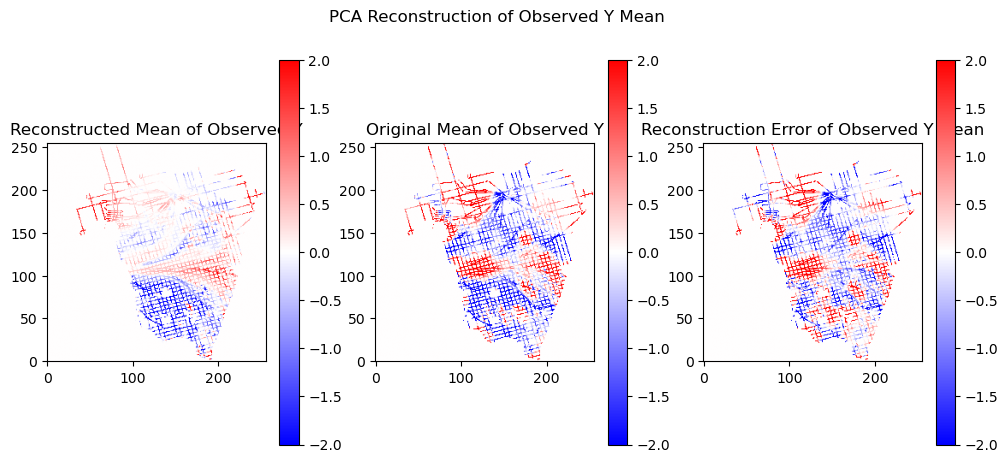

In [24]:
mu_obs_recons = pca_Y.inverse_transform(mu_obs_latent)
mu_obs_recons_img = mu_obs_recons.reshape(256, 256)

mu_obs_recons_err =  Y_obs_mean.flatten()-mu_obs_recons
mu_obs_recons_err_img = mu_obs_recons_err.reshape(256, 256)
plt.figure(figsize=(12, 5))
plt.subplot(1,3,1)
plt.imshow(mu_obs_recons_img, cmap='bwr', vmin=-2, vmax=2)
plt.title('Reconstructed Mean of Observed Y')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1,3,2)
plt.imshow(Y_obs_mean, cmap='bwr', vmin=-2, vmax=2)
plt.title('Original Mean of Observed Y')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1,3,3)
plt.imshow(mu_obs_recons_err_img, cmap='bwr', vmin=-2, vmax=2)
plt.title('Reconstruction Error of Observed Y Mean')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('PCA Reconstruction of Observed Y Mean')
plt.show()


conditioned indices are:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
x indices are:  [20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43
 44]


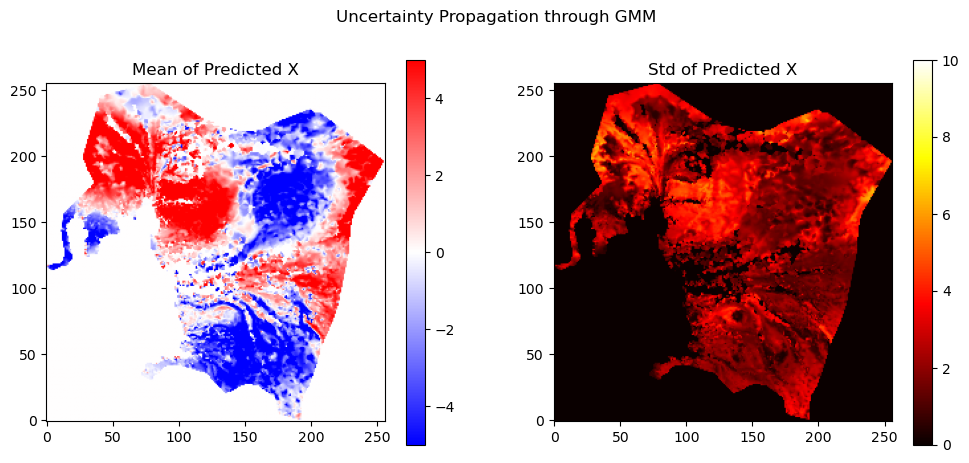

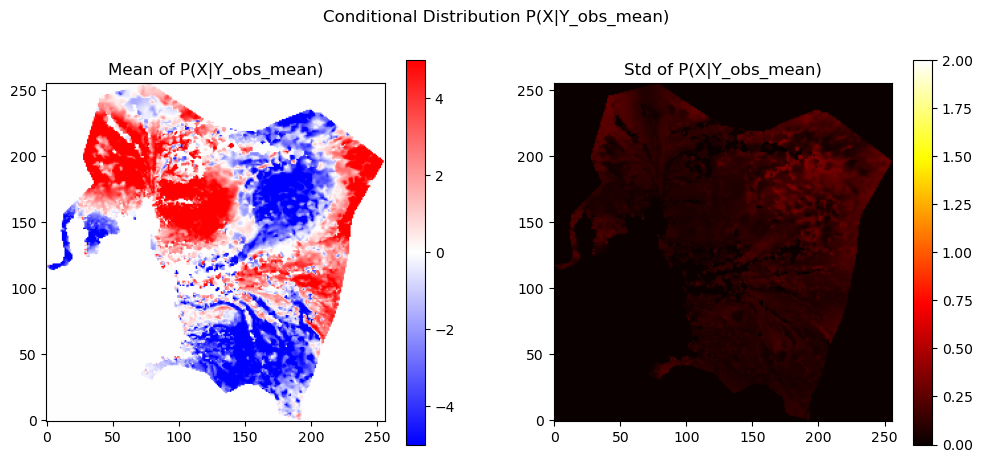

In [25]:
# propagate the observational uncertainty through the GMM to get the uncertainty in X
gmm_propagated = propagate_uncertainty(mu_obs_latent.T, cov_obs_latent, gmm, np.arange(ndim_Y), XY_train[:,:ndim_Y])

# sample from gmm_propagated to get the distribution of X
n_samples = 300
X_samples = gmm_propagated.sample(n_samples)
X_samples_ori = np.zeros((256*256, n_samples))
for i, sample in enumerate(X_samples):
    X_samples_ori[:,i] = pca_X.inverse_transform(sample)

# visualize the mean and variance
X_samples_mean = np.mean(X_samples_ori, axis=1).reshape(256, 256)
X_samples_std = np.std(X_samples_ori, axis=1).reshape(256, 256)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(X_samples_mean, cmap='bwr', vmin=-5, vmax=5)
plt.title('Mean of Predicted X')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(X_samples_std, cmap='hot', vmin=0, vmax=10)
plt.title('Std of Predicted X')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('Uncertainty Propagation through GMM')
plt.show()

# clear x_samples_ori to save memory
del X_samples_ori

# see what P(X|Y) looks like when Y is Y_obs_mean
pred_gmm = gmm.condition(np.arange(ndim_Y), mu_obs_latent.flatten())
pred_samples = pred_gmm.sample(300)
pred_samples_ori = np.zeros((256*256, 300))
for i, sample in enumerate(pred_samples):
    pred_samples_ori[:,i] = pca_X.inverse_transform(sample)

pred_samples_mean = np.mean(pred_samples_ori, axis=1).reshape(256, 256)
pred_samples_std = np.std(pred_samples_ori, axis=1).reshape(256, 256)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(pred_samples_mean, cmap='bwr', vmin=-5, vmax=5)
plt.title('Mean of P(X|Y_obs_mean)')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(pred_samples_std, cmap='hot', vmin=0, vmax=2)
plt.title('Std of P(X|Y_obs_mean)')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('Conditional Distribution P(X|Y_obs_mean)')
plt.show()

# Finding Maximum A Posteriori in the latent space